# Ultimate Questions

## Does the team you play on effect batting performance?
## What performance metric affects players salary most?
## Which effects players salary more: traditional or advanced statistics?

### Ultimatly the point of my project is finding out to what extent do different performance metrics influence player salaries in Major League Baseball?”

Importing all Libraries needed for webscraping

In [4]:
import requests
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup  #this is the spell that helps you read tags"
# from pathlib import Path, PureWindowsPath # For windows only 
import os 
import pandas as pd
import time
from time import sleep
import selenium #Need this step 
from selenium import webdriver #Need this step 

from selenium.webdriver.common.by import By #Allows for selenium to click things 
from selenium.webdriver.chrome.service import Service #https://stackoverflow.com/questions/64717302/deprecationwarning-executable-path-has-been-deprecated-selenium-python
from selenium.webdriver.support import expected_conditions as EC #Allows for more complex code 
from selenium.webdriver.chrome.options import Options #Allows you to change aspects of the browser

# Gathering Data

### All data gathered is from MLB season 2025

## Scraping data with BeautifulSoup

Below is player and home run data that I scraped with beautifulSoup.

I first used a for loop to loop through all 32 pages of the website.
Then I used get requests to retrieve the data I wanted.
I used beautifulSoup to parse through the whole webpage.
Then I retrieved both player links and homerun data using find.all 

For players, I needed to format the players name so it would be first and last name in my list. So I use another for loop to loop through each tag that was found above. Then finds all first and last name spans inside a. I make sure we have both first and last name link and indicate that first span is first name and second is last name for each player. I then create a new variable with first and last name and append all names to my players empty list. To clean the players variable I used AI to help me. 
    
For homeruns, I created a for loop to loop through each link in the list tag_hr and I get the text within the node in that list item link from the website. I then append that text (x1) to my empty list homers.
    
Finally I check that my code worked by checking the first player in players and the first number in homers and seeing if it corresponds to the website data as well as if the length of each list is the same.

In [6]:
#players name in mlb
players = [] #creates empty list called players
homers = [] #creates empty homers list
for i in range(1, 32):
    mlb_url1 = f"https://www.mlb.com/stats/2025?page={i}" #loops through all 31 pages on mlb site

# Use requests to retrieve data from a given URL
    mlb_response1 = requests.get(mlb_url1)
# Parse the whole HTML page using BeautifulSoup
    mlb_soup1 = BeautifulSoup(mlb_response1.text, 'html.parser')

 # find all player and homers tag and put them in a list
    player_links = mlb_soup1.find_all('a', class_='bui-link') #find all a tags on the page that have class bui-link
    tag_hr = mlb_soup1.find_all('td', {'class':'selected-h6IPIIxg number-GoaicxKV align-right-TwjGe_gi is-table-pinned-lGP8KWTK'})  #get the tags for the teams

    for link in player_links: #loops through each tag found 
        # find first and last name spans inside this <a>
        spans = link.find_all('span', class_='full-G_bAyq40') #finds all elemnets with class specified
        if len(spans) >= 2:  # make sure we have first and last name (2 elements in link
            first_name = spans[0].get_text(strip=True)
            last_name = spans[1].get_text(strip=True)
            #indicated first span is first name and second span is last name
            full_name = f"{first_name} {last_name}" #creates 1 variable with first and last name
            players.append(full_name) #appends names to a list called players
    
    for link in tag_hr: # for each link in the list tags
        x1 = link.get_text()  # get the text within the node in that list item link
        homers.append(x1) #append it to the list called homers


In [14]:
print(f'Element 1 of list players is {players[0]} and the length is {len(players)}') #check if it worked
print(f'Element 1 of list homers is {homers[0]} and the length is {len(homers)}') #check if it worked

Element 1 of list players is Cal Raleigh and the length is 765
Element 1 of list homers is 60 and the length is 765


## Scraping site 1 data with Selenium 

I had to use selenium for the rest of my project because the remaining data I needed is coded in Java.

Because of this I first had to establish a web driver. I used the same window size for all my websites because if I didn't it could change how the code interacts with the website and I didn't want risk that.

I have the same for loop going as before to loop through all pages of mlb website for stats that I need and empty lists for average, rbis, and ops for the data can go into.

This for loop loops through all pages of mlb website (31). It uses selenium's chrome WebDriver to open the page in browser and waits up to 7 seconds for the data to load before sending an error message in the code.

The nested forloop loops through each row in the table (each player) and extracts the text from the specified rbi, average, and ops columns (specifid through the XPath). It then drops each element into its own list. It is inside a try block to avoid errors if there is any missing data for a row. The except and continue is there because if there is any missing data, the code accepts it and moves onto the next row instead of stopping. 

Last I check that It worked by making sure the first element in each list is Cal Raleigh's stats and that the list length is the same.

In [11]:
chrome_options = Options()
driver = webdriver.Chrome() # Initialize
chrome_options.add_argument("--window-size=1900,1000") #pick a size and stick with it, it can change how code intreacts with the website.
driver = webdriver.Chrome(options = chrome_options) #establish driver
from selenium.webdriver.common.by import By

mlb_rbis = [] 
mlb_average = []
mlb_ops = [] 

for i in range(1, 32):
    mlb_url1 = f"https://www.mlb.com/stats/2025?page={i}"
    
    driver.get(mlb_url1) #Uses Selenium’s Chrome WebDriver to open the page in a browser
    driver.implicitly_wait(7) #Tells Selenium to wait up to 7 seconds for elements to load before throwing an error
    rows = driver.find_elements(By.XPATH, '//*[@id="stats-app-root"]/section/section/div[4]/div[1]/div/table/tbody/tr') #Finds all table rows t in the stats table on the page. Returns row elements
    
    for row in rows: #loops through each row in table (each player)
        try:
            rbi = row.find_element(By.XPATH, './td[9]').text #Looks inside the current row (.) for the 9th <td> element (the rbi column) and extracts text
            mlb_rbis.append(int(rbi)) #Converts the RBI value from a string to an integer and adds the number to mlb_rbi list
            
            avg = row.find_element(By.XPATH, './td[14]').text #Looks inside the current row for the 14th element (the batting average) and extracts the number as a string
            mlb_average.append(float(avg)) #appends to the list mlb_average as a float instead of string
            
            ops = row.find_element(By.XPATH, './td[17]').text #Looks inside the current row for the 17 element (ops) and extracts the number as a string
            mlb_ops.append(float(ops)) #appends the number as a float to list mlb_ops
        except:
            continue
#Inside a try block to avoid errors if a row doesn’t have an RBI value. 
# except/continue: If there’s an error (e.g., RBI column missing, text not an integer), it skips that row and continues to the next row.

In [13]:
print(f'Element 1 of list mlb_rbis is {mlb_rbis[0]} and the length is {len(mlb_rbis)}') # check it worked
print(f'Element 1 of list mlb_average is {mlb_average[0]} and the length is {len(mlb_average)}') #check it worked
print(f'Element 1 of list mlb_ops is {mlb_ops[0]} and the length is {len(mlb_ops)}') #check it worked

Element 1 of list mlb_rbis is 125 and the length is 765
Element 1 of list mlb_average is 0.247 and the length is 765
Element 1 of list mlb_ops is 0.948 and the length is 765


## Putting data into dataframe using pandas

After scraping all data from the first website that I need I am them going to put all the lists created into one dataframe. I am going to put all elements 1 of each list in the same row for all 765 players. 

DF1 is a structured dataframe that is going to be merged with another dataframe later.

Finally I check if the first 5 rows in the dataframe is correct and print the number of rows in the dataframe (if it is 765 than it is correct)

In [15]:
df1 = pd.DataFrame({ #creates new pandas dataframe
    'Player': players, #creates column called player and uses my list players
    'OPS': mlb_ops, #creates column called OPS and uses my mlb_ops list
    'HR': homers, #creates column called HR and uses my homers list
    'BattingAvg': mlb_average, #creates column called BattingAVG using my mlb_average list
    'RBI': mlb_rbis #creates column called RBI using my mlb_rbi list
})
#I did this way because all my lists are from the same sites which means they are all same lenghth (i double checked before)
#The index allignment is by list order (first element of each list corresponds iwth the same player)
#df1 is a structured table of player stats that can be merged with other dataframes

In [18]:
print(df1.head())
print(f'The length of df1 is {len(df1)}')

           Player    OPS  HR  BattingAvg  RBI
0     Cal Raleigh  0.948  60       0.247  125
1  Kyle Schwarber  0.928  56       0.240  132
2   Shohei Ohtani  1.014  55       0.282  102
3     Aaron Judge  1.145  53       0.331  114
4  Eugenio Suárez  0.824  49       0.228  118
The length of df1 is 765


## Scraping site 2 data with selenium

I scraped site 2 the same way as I scraped site 1 with selenium. 
I inititalized a driver and kept the window size the same so my code is uniformed throughout.

I created another for loop for this site so the code loops through all 48 pages at once. Then my driver opens up the url and finds the element I want by XPATH which I got through the site's code. I tell it to find the players name, salary, team, and position. Scince I am just scraping the data from the website the element structure is not how I want it to be so I will have to clean the lists after the data is put into them.

I then check to see if the data scraped properly.

In [23]:
players2 = []
salary = []
team = []
position = []

chrome_options = Options()
driver = webdriver.Chrome() # Initialize
chrome_options.add_argument("--window-size=1900,1000") 
driver = webdriver.Chrome(options = chrome_options) #establish driver

for i in range(1, 49):
    mlb_url2 = f"https://databases.usatoday.com/major-league-baseball-salaries-2025/page/{i}/" #loops through all 48 pages on mlb site
    
    driver.get(mlb_url2) #opens url in browser
    driver.implicitly_wait(7) #waits 7 seconds for elemnets to load before error message
    
    rows = driver.find_elements(By.XPATH, '//*[@id="csp-data"]/div[3]/div/div/div[1]/table/tbody/tr')
    #finds all elements in table. returns list of rows. The XPATH points to the <tbody> of the table where each row represents a player.
    for row in rows: #loops through each row in table 
        try:
            mlb_players = row.find_element(By.XPATH, './td[1]').text #finds first cell in current row (player name) and extracts as string
            players2.append(mlb_players) #appends name to players name
            
            player_sal = row.find_element(By.XPATH, './td[4]').text #finds 4 cell in current row (salary) and extracts as string
            salary.append(player_sal) #adds vaue to empty list
            
            mlb_team = row.find_element(By.XPATH, './td[2]').text #finds 2 cell in current row (team) and extracts as string
            team.append(mlb_team) #appends the string to the list team
            
            mlb_pos = row.find_element(By.XPATH, './td[3]').text #finds 3 cell in current row (position) and extracts as string
            position.append(mlb_pos) #appends to list mlb position
        except:
            continue


In [25]:
print(f' First player:{players2[0]} length of list:{len(players2)}') #check
print(f' First salary:{salary[0]} length of list:{len(salary)}') #check
print(f' First team:{team[0]} length of list:{len(team)}') #check
print(f' First position:{position[0]} length of list:{len(position)}') #check

 First player:Soto, Juan length of list:954
 First salary:$61,875,000 length of list:954
 First team:Mets length of list:954
 First position:OF length of list:954


## Cleaning lists from second website

Most lists that we just collected has to be cleaned so the data is better presented and can be analyzed.

The players list has to match how the players are represented in list 1 (First Last name) so the dataframes can be merged properly. In this list it is last,first. So we have to strip the comma from each name and swap the name positions. I do this by creating a for loop, checking to see if the name has a comma in it and if it does the loop splits the name by comma. Then I strip any extra spaces and quotes around the name if there are any. If the name does not have a comma in it then it is asusmed it is in corrected format already. The else condition is only there for percausion. Then it appends each name to the corrected players2 list. At the end I check it it worked. 

For Salary, right now the type is string, and we need to make integer and strip the commas and dollar signs from each salary. The loop, loops through the salary list and replaces the comma and $ in each element in the list and stores it to a new list as an integer type.

For positions on the website third base is just the number 3, first base is just the number 1. I don't like this because it might be confusing to some people that don't know a lot about baseball. Furthermore, some data types are string and some are integer. I want to clean this so it makes more sense and is easier to use for analysis. I do this by a simple for loop, looping through all positions in clean_position list (which is a copy of original position list) and if the data equals 1, 2, or 3 it changes to equaling 1B, 2B, and 3B.

I print the first item of each list to make sure that it corresponds to the correct player, the data is cleaned, and it is still same length as before 

** Disclaimer I used AI to help me clean players list and salary list **

In [27]:
#correcting players
corrected_players2 = [] #new empty list for corrected format

for name in players2: #loops through original players2 list
    if "," in name: #checks if string has comma and if it does the string needs to be fixed
        parts = name.split(",") #splits string at the comma to 2 parts
        full_name = parts[1].strip() + " " + parts[0].strip() #part[1] is first name and part[0] is the last name. strip removes any extra spaces so the format is in First Last
    else:
        full_name = name.strip() #if name does have comma order is assumed to be in First Last and removes any extra spaces. This is here just for percausion but every name has a comma 
    corrected_players2.append(full_name) # appends full name in correct format to the list corrected_players2

#correcting salaries
salaries_int = [int(s.replace("$","").replace(",","")) for s in salary]

#correcting positions
clean_pos = position
for i in range(len(clean_pos)): #loops through entire position list
    if clean_pos[i] == '1':
        clean_pos[i] = "1B" #if value = 1 change to 1B
    elif clean_pos[i] == '2':
        clean_pos[i] = "2B" #if value = 2 change to 2B
    elif clean_pos[i] == '3':
        clean_pos[i] = "3B" #if value =3 change to 3B

#checking
print(f' First player:{corrected_players2[0]} length of list:{len(corrected_players2)}') 
print(f' First salary:{salaries_int[0]} length of list:{len(salaries_int)}')
print(f' First position:{clean_pos[0]} length of list:{len(clean_pos)}')

 First player:Juan Soto length of list:954
 First salary:61875000 length of list:954
 First position:OF length of list:954


## Puting all data scraped from website 2 into a dataframe

Just like before, all information was extracted from the same website. I put all my lists into a dataframe saving it as df2. I was able to do this because all my first elements match with the first player and all my lists were same lenghth

I checked the length of my dataframe and the first 5 rows just like before to make sure the dataframe saved properly

In [29]:
df2 = pd.DataFrame({
    "Player": corrected_players2,
    "Position": clean_pos,
    "Team": team,
    "Salary": salaries_int
})

#checking
print(df2.head())
print(f'The length of df1 is {len(df2)}')

           Player Position      Team    Salary
0       Juan Soto       OF      Mets  61875000
1    Zack Wheeler      RHP  Phillies  42000000
2     Aaron Judge       OF   Yankees  40000000
3    Jacob deGrom      RHP   Rangers  40000000
4  Anthony Rendon       3B    Angels  38571429
The length of df1 is 954


## Scraping data website 3 with selenium

This ESPN website I only need to scrape 4 pages. I decided to put all them in a list instead of a for loop because the page numbers that I need are not consecutive based on how the website is laid out. 

My loop loops through the 4 websites in the list, finds the table rows with the statistics needed and returns the players name, war, and off into 3 seperate lists. It finds elements by XPath

Lastly I checked to see if it worked by checking all lists lenghth and is first element corresponds with other first elements.

This particular website only had 198 players on it, so it did scrape properly there was just severly less data to pull than from the first 2 websites.

In [36]:
mlb_url3 = ['https://www.espn.com/mlb/war/leaders/_/year/2025/type/seasonal/alltime/false/count/1', 
           'https://www.espn.com/mlb/war/leaders/_/year/2025/type/seasonal/alltime/false/count/51',
           'https://www.espn.com/mlb/war/leaders/_/year/2025/type/seasonal/alltime/false/count/101',
           'https://www.espn.com/mlb/war/leaders/_/year/2025/type/seasonal/alltime/false/count/151']
chrome_options = Options()
driver = webdriver.Chrome() # Initialize
chrome_options.add_argument("--window-size=1900,1000") #pick a size and stick with it, it can change how code intreacts with the website.
driver = webdriver.Chrome(options = chrome_options) #establish driver
from selenium.webdriver.common.by import By

mlb_war = []
mlb_off = []
mlb_player3 = []

for url in mlb_url3:
    driver.get(url) #Uses Selenium’s Chrome WebDriver to open the page in a browser
    driver.implicitly_wait(7) #Tells Selenium to wait up to 7 seconds for elements to load before throwing an error
    rows = driver.find_elements(By.XPATH, '//*[@id="my-players-table"]/div/div[1]/table/tbody/tr')
    
    for row in rows: #loops through each row in table (each player)
        try:
            war = row.find_element(By.XPATH, './/td[3]').text
            mlb_war.append(float(war)) 
            
            off = row.find_element(By.XPATH, './/td[4]').text
            mlb_off.append(float(off))
            
            player3 = row.find_element(By.XPATH, './/td[2]//a').text
            mlb_player3.append(player3)
        except:
            continue
            

In [37]:
print(f' First player:{mlb_player3[0]} length of list:{len(mlb_player3)}') #check
print(f' First war:{mlb_war[0]} length of list:{len(mlb_war)}')
print(f' First off:{mlb_off[0]} length of list:{len(mlb_off)}')

 First player:Aaron Judge length of list:198
 First war:9.7 length of list:198
 First off:9.4 length of list:198


## Putting scraped data from website 3 into dataframe

In [38]:
df3 = pd.DataFrame({
    "Player": mlb_player3,
    "OFF": mlb_off,
    "WAR": mlb_war,
})

#check
print(df3.head())
print(f'The length of df1 is {len(df3)}')

               Player  OFF  WAR
0         Aaron Judge  9.4  9.7
1  Cristopher Sanchez  0.0  8.0
2       Shohei Ohtani  6.6  7.7
3         Paul Skenes  0.0  7.6
4         Cal Raleigh  7.7  7.3
The length of df1 is 198


# Merging

For merging I decided to create 2 CSV files. One of them with only merged data from df1 and df2. This is because this CSV would have a lot more data since there are more players in both these datasets. 

I wanted to merge WAR with the other 2 dataframes because it is a great stat for baseball analysis, especially when analyzing which performance metrics correalate to salary the most. 

When I merged df1 and df2 it dropped all players that are only in 1 dataframe but not both. Since I have different players in each dataset due to the fact that I scraped different websites to get the statistics I needed, when the 2 dataframes merged it dropped a lot of my players that I originally scraped. However there are still a lot of overlapping player that makes my dataset over 400 players.

The first CSV was merged on player name between df1 and df2. Only keeps players in both dataframes and all data corresponding to the player in in one line. When looking at my summary statistics I can tell that it merged properly based on how many unique players there are and all data rows have the same count. However, I have 4 rows with the same player name. I manually look into this and notice that only rows 81 and 84 is correct data. This name was the only one that didn't merge as expected because there are 2 different mlb players with the same name (Max Muncy) that played in the 2025 season. I just dropped the 2 incorrect rows and saved the dataframe into a CSV.

With my second CSV file I knew it was going to be a lot smaller just because the website that I scraped to get players WAR and OFF stats only had 198 players on it for the 2025 bseball season. So I decided to create a second CSV file merging those statistics so that when I create graphs and regressions I can use the larger data set for graphs that don't include variables WAR and OFF. I like to work with larger datasets so outliars don't effect the results as much.

I merged these dataframes the same way as the first 2 (by player) and printed out the summary statistics to check that it merged properly which it did. Saving it into another CSV file to be used for graphs and analysis later. 

In [47]:
merged_df = pd.merge(df1, df2, on=["Player"], how="inner")

print(merged_df.head())
print(len(merged_df))
print(merged_df.describe(include='all')) #this gives me descriptive statistics so I can check it merged properly and includes all datatypes not just continuous

            Player    OPS  HR  BattingAvg  RBI Position      Team    Salary
0      Cal Raleigh  0.948  60       0.247  125        C  Mariners   2666667
1   Kyle Schwarber  0.928  56       0.240  132       DH  Phillies  20000000
2    Shohei Ohtani  1.014  55       0.282  102   DH/RHP   Dodgers  28213523
3      Aaron Judge  1.145  53       0.331  114       OF   Yankees  40000000
4  Junior Caminero  0.846  45       0.264  110       3B      Rays    764100
431
           Player         OPS   HR  BattingAvg         RBI Position  \
count         431  431.000000  431  431.000000  431.000000      431   
unique        428         NaN   44         NaN         NaN       11   
top     Max Muncy         NaN    0         NaN         NaN       OF   
freq            4         NaN   94         NaN         NaN      127   
mean          NaN    0.593599  NaN    0.204327   36.983759      NaN   
std           NaN    0.267535  NaN    0.096299   31.321472      NaN   
min           NaN    0.000000  NaN    0.000

In [42]:
merged_df[merged_df.duplicated(subset='Player', keep=False)]

,Player,OPS,HR,BattingAvg,RBI,Position,Team,Salary
81,Max Muncy,0.846,19,0.243,67,3B,Dodgers,14250000
82,Max Muncy,0.846,19,0.243,67,2B,Athletics,760000
83,Max Muncy,0.638,9,0.214,23,3B,Dodgers,14250000
84,Max Muncy,0.638,9,0.214,23,2B,Athletics,760000


In [50]:
merged_df = merged_df.drop(index=[82, 83])

In [51]:
merged_df.to_csv("mlb_data.csv", index=False)
df_check = pd.read_csv("mlb_data.csv") #creating CSV
print(df_check.head())

            Player    OPS  HR  BattingAvg  RBI Position      Team    Salary
0      Cal Raleigh  0.948  60       0.247  125        C  Mariners   2666667
1   Kyle Schwarber  0.928  56       0.240  132       DH  Phillies  20000000
2    Shohei Ohtani  1.014  55       0.282  102   DH/RHP   Dodgers  28213523
3      Aaron Judge  1.145  53       0.331  114       OF   Yankees  40000000
4  Junior Caminero  0.846  45       0.264  110       3B      Rays    764100


In [53]:
merged_df2 = pd.merge(merged_df, df3, on="Player", how="inner")

print(merged_df2.head())
print(len(merged_df2))
print(merged_df2.describe(include='all'))

            Player    OPS  HR  BattingAvg  RBI Position      Team    Salary  \
0      Cal Raleigh  0.948  60       0.247  125        C  Mariners   2666667   
1   Kyle Schwarber  0.928  56       0.240  132       DH  Phillies  20000000   
2    Shohei Ohtani  1.014  55       0.282  102   DH/RHP   Dodgers  28213523   
3      Aaron Judge  1.145  53       0.331  114       OF   Yankees  40000000   
4  Junior Caminero  0.846  45       0.264  110       3B      Rays    764100   

   OFF  WAR  
0  7.7  7.3  
1  4.9  4.7  
2  6.6  7.7  
3  9.4  9.7  
4  4.9  4.5  
115
           Player         OPS   HR  BattingAvg         RBI Position  Team  \
count         115  115.000000  115  115.000000  115.000000      115   115   
unique        114         NaN   38         NaN         NaN       11    29   
top     Max Muncy         NaN    0         NaN         NaN       OF  Cubs   
freq            2         NaN    9         NaN         NaN       35     9   
mean          NaN    0.746922  NaN    0.250765   67.

In [54]:
merged_df2.to_csv("mlb_data2.csv", index=False) #creating CSV
df_check2 = pd.read_csv("mlb_data2.csv")
print(df_check2.head())

            Player    OPS  HR  BattingAvg  RBI Position      Team    Salary  \
0      Cal Raleigh  0.948  60       0.247  125        C  Mariners   2666667   
1   Kyle Schwarber  0.928  56       0.240  132       DH  Phillies  20000000   
2    Shohei Ohtani  1.014  55       0.282  102   DH/RHP   Dodgers  28213523   
3      Aaron Judge  1.145  53       0.331  114       OF   Yankees  40000000   
4  Junior Caminero  0.846  45       0.264  110       3B      Rays    764100   

   OFF  WAR  
0  7.7  7.3  
1  4.9  4.7  
2  6.6  7.7  
3  9.4  9.7  
4  4.9  4.5  


# Graphing

Importing data and functions

In [49]:
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

mlb_data1= pd.read_csv(r'C:\Users\lamas\OneDrive\Documents\eco590\assignment-1-Jesslamastra\mlb_data.csv')
mlb_data2= pd.read_csv(r'C:\Users\lamas\OneDrive\Documents\eco590\assignment-1-Jesslamastra\mlb_data2.csv')

### Boxplot and barchart of OPS by team

I want this to be my first graph to visually see the different variation in data regarding team when looking at ops. This graph helps see if players on certain teams have higher batting statistics. I used ops because that is on base plus slugging percent so when choosing which variable to use this is a good one because it is a good measure of overall batting performance. I thought it would be good to look at them side by side as well to see what the variation of OPS is like per team (box chart) and what the mean OPS varries per team (bar chart).

I found it easier to build both graphs in seaborn and then plot them side by side in one figure. First graph I built a boxplot to see how ops varry amung teams. This shows me that some teams have higher ops than others. It could be many factors like star players, homefeild, season luck, but because the teams OPS have a decent amount of variation according to the graph, it would be good to include in a regression to analyze further.

The second bar graph plots teams mean OPS. This is good to see to look at how teams OPS differ from each other. The graph shows that mean ops ranges from a little above .5 to a little over 1. This tells me that it has enough variation to include in a regression. 

It is good to look at the graphs side by side because the boxplot shows variation in data and the bar graph just shows how the data is different in team to team. 

#### Code Explained
I first created a cleaned dataset by dropping all the pitchers except for the ones that pitch and bat from the data set. this is because 98% of pitchers in MLB don't bat throughout the season and have a 0 value for most batting metrics. So I dropped these players from my larger CSV so the would not skew my data. I didn't drop them from the smaller (second CSV) file because all players have a calculated WAR and OFF becaue these are not just batting metrics, they are measured by combined offense and defence metrics. 

To create the graphs I ordered the teams from least to greatest median OPS so the order of the teams will be the same when looking at two graphs. I did this by finding the median team OPS instead of players using groupby and extracting the team name value to graph. Then I plotted the data using my larger CSV file.

I put the two graphs together by creating subplots and including one graph to the right and one to the left side by side. Then I saved the image

I used AI to help me sort the teams by median for each graph as well as to put them in one figure because I was confused on how to do that in seaborn.

In [13]:
mlb_data1_clean = mlb_data1[(mlb_data1['OPS'] != 0) & (mlb_data1['OPS'] != 2)]

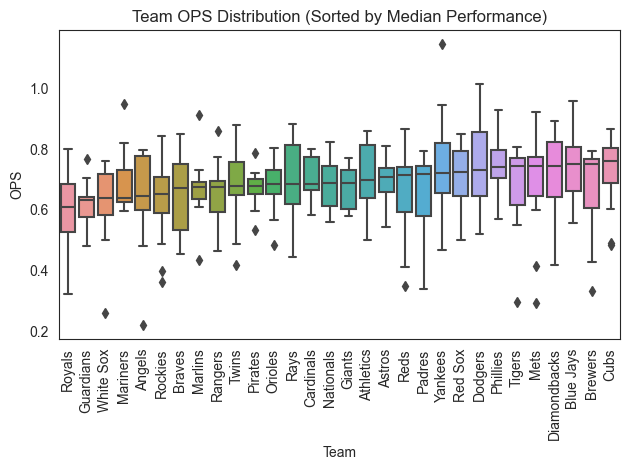

In [67]:
sns.set_style("white")

order = mlb_data1_clean.groupby('Team')['OPS'].median().sort_values().index #orders team by least to greatest median

ax = sns.boxplot(x='Team', y='OPS', data=mlb_data1_clean, order=order) #creates boxplot

plt.xticks(rotation=90) #rotates x ticks 90 degrees
plt.title("Team OPS Distribution (Sorted by Median Performance)") #title of graph

plt.tight_layout()

plt.savefig("OPSbyTeam_boxplt.png", dpi=300)  # saves as PNG
plt.show()



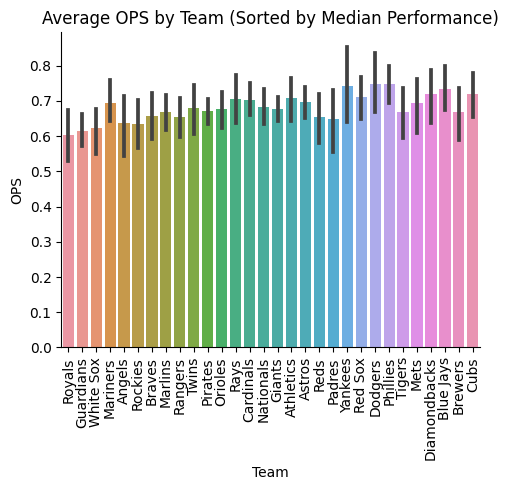

In [4]:
order = mlb_data1_clean.groupby('Team')['OPS'].median().sort_values().index
ax = sns.catplot(x= 'Team',y = 'OPS',data= mlb_data1_clean, order=order, kind='bar')

plt.xticks(rotation=90)
plt.title("Average OPS by Team (Sorted by Median Performance)")

plt.tight_layout()

plt.savefig("OPSbyTeam_bar.png", dpi=300)  # saves as PNG
plt.show()


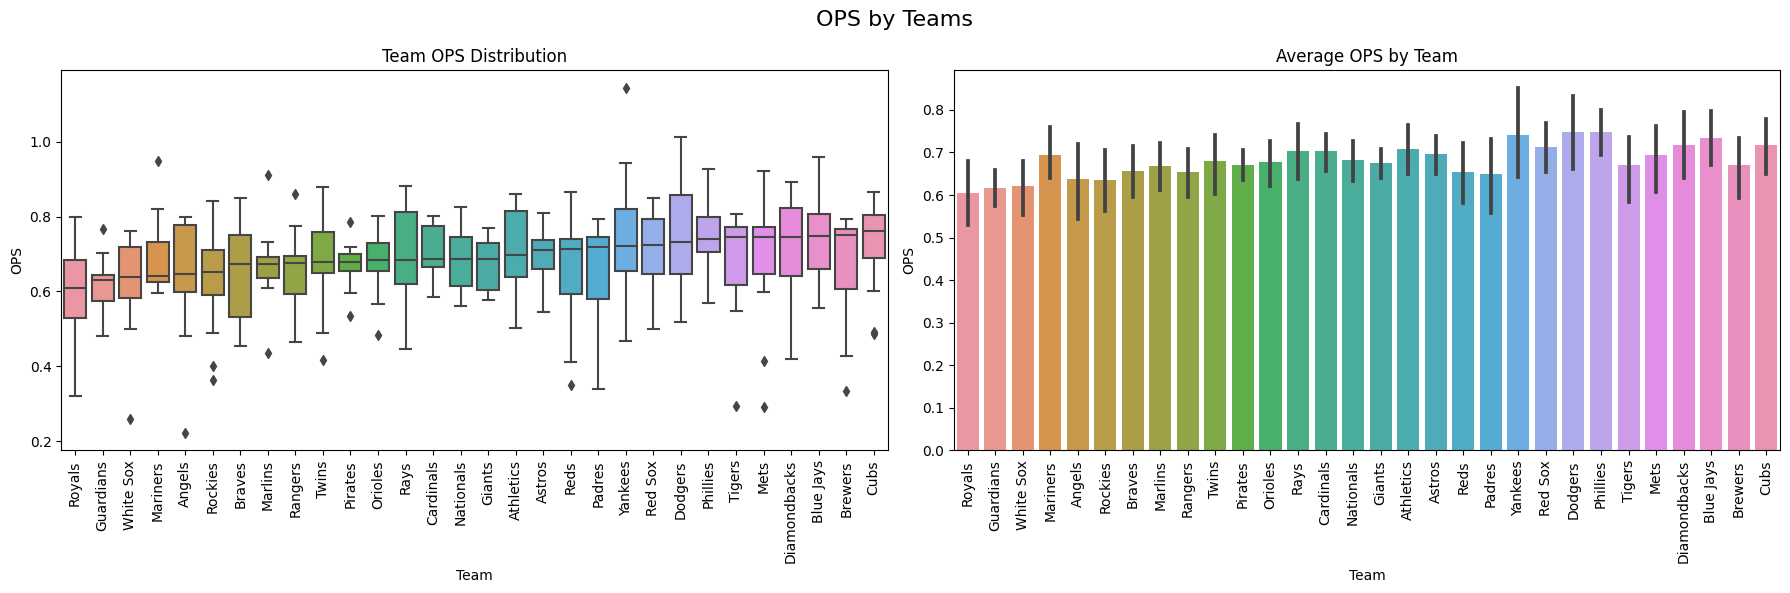

In [55]:
order = mlb_data1_clean.groupby('Team')['OPS'].median().sort_values().index #orders team by median so the teams are in same order for both graphs

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18,6)) #plots subplots

#Boxplot
sns.boxplot(x='Team', y='OPS', data=mlb_data1_clean, order=order, ax=ax1) #plots boxplots
ax1.set_title("Team OPS Distribution") #title
ax1.tick_params(axis='x', rotation=90) #roatates x tick lables vertically

#Barplot
sns.barplot(x='Team', y='OPS', data=mlb_data1_clean, order=order, ax=ax2) #plots barchart
ax2.set_title("Average OPS by Team") #title
ax2.tick_params(axis='x', rotation=90) # rotates x axsis ticks vertically

fig.suptitle("OPS by Teams", fontsize=16) #overall title

plt.tight_layout()
plt.savefig('TeamXops.png', dpi=300) #saves image
plt.show()

### Correalation Heatmap

I chose to make a correalation heatmap to show which variables are strongly linked to salary and each other. Many batting metrics measure the same thing in different ways (for example ops measures home run plus on base percentage and HR measures homerun). This heatmap allows me to see the correalation between my variables so I can know which ones will add additional information when I do regressions and which variables might cause multicollineararity. It also shows which statistics are more highly linked to salary which is good information to have when thinking about what variables to include in regressions. 

I first had to get the correlation matrix between all continous variables using .corr function. I specified having a coolwarm color scheme and I wanted to have the correalation values shown in every box rounding to 2 decimal places for readability. 

Looking at the graph I can see that WAR and OFF are more correalated to salary than OPS. Also batting average and OPS are very highly correalated so I know if I include both variables in a regression the regression will be suceptable to multicolineararity. 

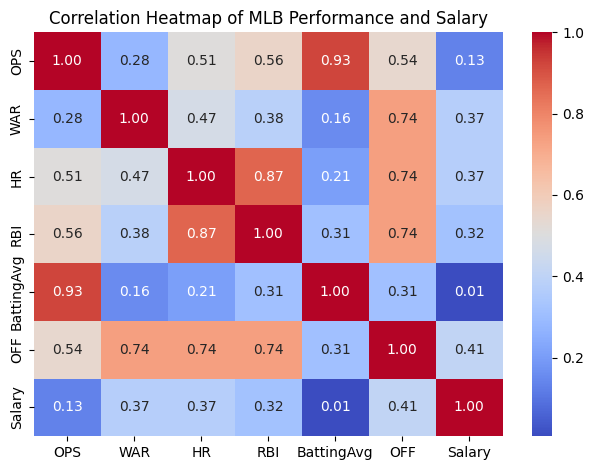

In [56]:
corr = mlb_data2[["OPS","WAR","HR","RBI","BattingAvg", "OFF", "Salary"]].corr() #getting correalation coefficents for each specified data

sns.heatmap(corr, cmap="coolwarm", annot=True, fmt='.2f') #plot heatmap with numbers in boxes rouded to 2 decimal points

plt.title("Correlation Heatmap of MLB Performance and Salary")

plt.tight_layout()
plt.savefig('heatmap.png', dpi=300)
plt.show()

### Scatterplot of Salary and OPS and Salary and WAR Colored by Position

To get this scatterplot I first had to temporarily make a new column in the data set which is salary in millions. This is so that the graph can be more easily read. I did this by using the .loc function. I created a row using the data that divided the Salary column by one hundred thousand for every row. Salary column is pay per year.

Then I created a color pallet so that both graphs would color each position with the same specified color and established 2 subplots. I created the first scatterplot salary on WAR with the salary in millions giving each position a different color. This allows us to see if some positions have higher WARS than others. Then I took the legend information from this scatterplot and removed in from being inside the graph. For the OPS graph, I plotted it the exact same way but remove dthe legend from the graph all together because both graphs are sharing one legend. I then titled the legend positions and places the legend in the center of both graphs and saved the image. 

The cluster at the bottom is all the rookie players making league minimum (760,000) per year. Because my salary data goes from 760,000-61,000,000 it looks like a bunch of players have 0 salary when in acuality they are just making league minimum and most likely rookies. I tried including salary by million, and by ten thousand but because the range is so high the clusters are still there no matter what unit.

I used AI to help me change the salary column.


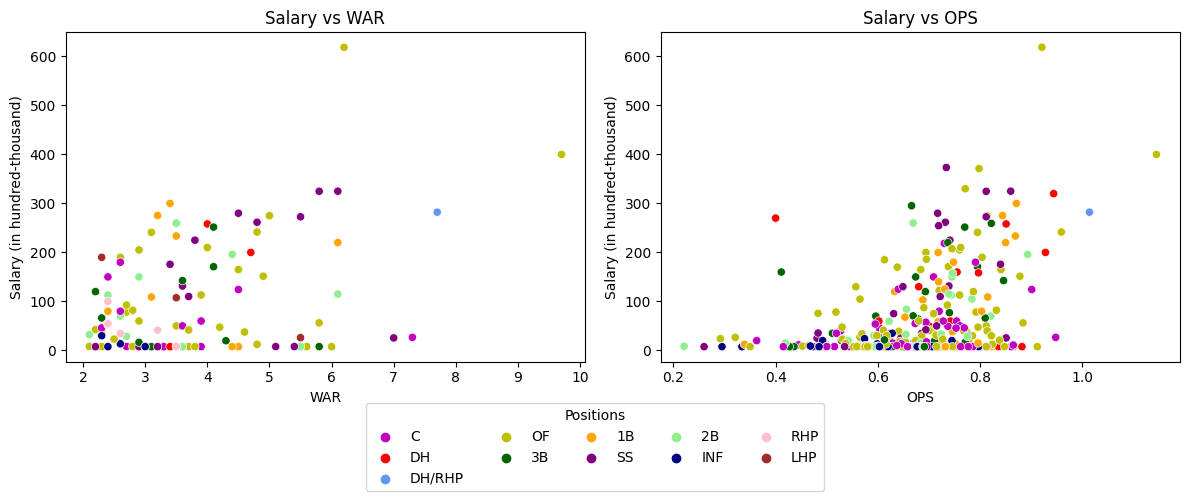

In [64]:
mlb_data2.loc[:, "Salary_hundthous"] = mlb_data2["Salary"] / 1e5 #creates salary in hundreds-thousands so y axsis is easy to read
mlb_data1_clean.loc[:, "Salary_hundthous"] = mlb_data1_clean["Salary"] / 1e5

palette = {
     'C': 'm',
    'DH': 'r',
    'OF': 'y',
    '3B':'darkgreen',
    'DH/RHP': 'cornflowerblue',
    '1B': 'orange',
    'SS': 'purple',
    '2B': 'lightgreen',
    'INF': 'navy',
    'RHP': 'pink',
    'LHP': 'brown'} #creates colors for each position

fig, axes = plt.subplots(1, 2, figsize=(12,5)) #creates subplots for 2 graphs 

#WAR graph
sns.scatterplot(x="WAR", y="Salary_hundthous", hue="Position", data=mlb_data2, ax=axes[0], palette=palette) #graphs scatterplot colorcoding for position

handles, labels = axes[0].get_legend_handles_labels() #saves legend information
axes[0].legend_.remove() #removes legend from inside the graph 

axes[0].set_title("Salary vs WAR")
axes[0].set_ylabel("Salary (in hundred-thousand)")

#OPS graph
sns.scatterplot(x="OPS", y="Salary_hundthous", hue="Position", data=mlb_data1_clean, ax=axes[1], legend=False, palette=palette) #plots scatterplot excluding legend

axes[1].set_title("Salary vs OPS")
axes[1].set_ylabel("Salary (in hundred-thousand)")

#layout
fig.legend(handles, labels, title="Positions", loc="lower center", ncol=5) #sets legend position
plt.tight_layout(rect=[0, 0.15, 1, 1]) #gives space between bottom of graph and legend and puts legend in middle of 2 graphs
plt.savefig('scatterplt.png', dpi=300)
plt.show()

In [66]:
print(" leauge minimum salary:", mlb_data2["Salary"].min())
print("highest salary:", mlb_data2["Salary"].max())
#this made me realize why the clusters were still there no matter the unit of y axis

 leauge minimum salary: 760000
highest salary: 61875000


### Histogram of Salary

Since salary for sports is often distributed very unevenly I wanted to see how uneven the salary is being distributed. This will help me determine if I should log salary in other graphs and regressions. As suspected most players salary are in between 0-10 million and yet my dataset goes to a player recieving a little above 60 million per year. 

This is because of star players and outliar contracts. I can't drop this data because it is esential to keep in my regression but I can log salary variable for a better and deeper analysis of how performance metrics effect salary. 

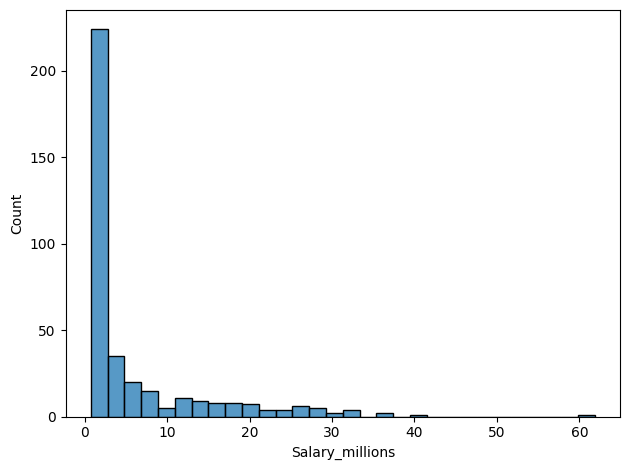

In [58]:
sns.histplot(mlb_data1_clean["Salary_hundthous"], bins=30) #plot histogram

plt.tight_layout() #helping layout
plt.savefig('histSal.png', dpi=300) #saving figure
plt.show()

### Grahing OPS and WAR on Logged Salary

As my histogram shows it is probably best for me to log salary to see how some metrics interact with pay. 

I first had to log my salary data locally using numpy and saving it to a column called Salary_log to use in the graph. I decided to log salary because the data varies tramendously, so the log helps normalize the data for better visualization.

Then I create the subplots and graph WAR on log_Salary and OPS on log_Salary. I decided to include regression lines to show the linear relaships between WAR and OPS when comparing it to salary.

When looking at the WAR vs Salary graph there is a clear upward trend but a wide spread of data. Since the confidence interval is quite large, it seems to be a factor in salary but might not nessacarily be a dominate one. However players with low WAR and high salary could be due to players age on long term contracts. 

When looking at OPS vs Salary graph there is also an upward trend as expected but the confidence interval is a lot narrower and the line of best fit is steeper. This could suggest that OPS is a stronger determinate of salary than WAR.

The clusters at the bottom of both graphs are all the players making league minimum (typically rookie contracts).

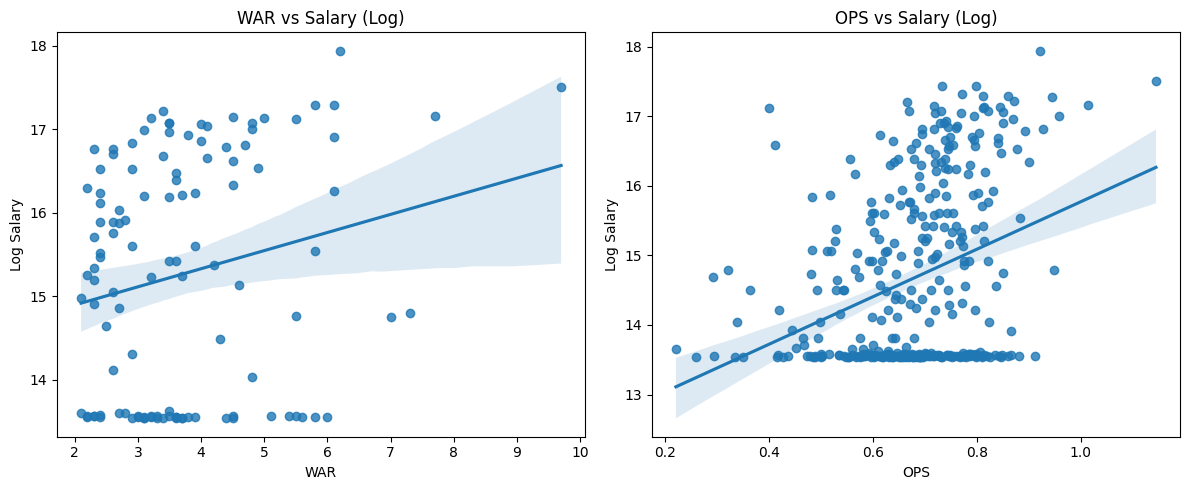

In [54]:
#logging salary
mlb_data2.loc[:, "Salary_log"] = np.log(mlb_data2["Salary"])
mlb_data1_clean.loc[:, "Salary_log"] = np.log(mlb_data1_clean["Salary"])

fig, axes = plt.subplots(1, 2, figsize=(12,5)) #set subplots

#WAR graph
sns.regplot(x="WAR", y="Salary_log", data=mlb_data2, ax=axes[0]) # plot scatterplot with regression line
axes[0].set_title("WAR vs Salary (Log)")
axes[0].set_xlabel("WAR")
axes[0].set_ylabel("Log Salary")

#OPS graph
sns.regplot(x="OPS", y="Salary_log", data=mlb_data1_clean, ax=axes[1]) #plot scatterplot with regression line
axes[1].set_title("OPS vs Salary (Log)")
axes[1].set_xlabel("OPS")
axes[1].set_ylabel("Log Salary")

#graph layout
plt.tight_layout()
plt.savefig('logSal.png', dpi=300)
plt.show()
